# `05_unsupervised_weighting.ipynb` — Unsupervised expert weighting for the contactless-AF fusion

**Why this notebook exists.** `04_validate.ipynb` builds three modality experts (cECG, PPG, BCG) and
blends them with a **supervised** gate: a small network that reads per-window SQI and is trained on the
**labels** `y` (BCE on the blended probability, or a per-expert routing target). That notebook's closing
section argues the gate can at best *match* the naive mean, because the label-driven routing signal is weak
and there are only ~40 independent patients.

This notebook attacks the problem from a different direction: **derive the blending weights with
*unsupervised* learning instead.** The weighting *mechanism* is kept identical to `04` — three softmax
weights over the experts, final probability $\hat p = \sum_m w_m\,p_m$ — but the learner that produces
$w_m$ **never sees the labels**. It looks only at the signal-quality structure (SQI).

**Why this is principled, not a workaround.**
- *Quality is observable without ground truth.* SQI measures detectability/morphology, not rhythm; a cleaner
  modality on a given window deserves more trust regardless of whether that window is AF. The label is the
  wrong teacher for "which modality to trust"; signal quality is the right one.
- *It removes the over-fitting bottleneck.* A supervised gate gets gradient mostly on disagreement windows
  and is fit on ~40 patients, so it slips below the mean. An unsupervised weighter is fit on the **SQI
  distribution** (tens of thousands of windows, no per-patient label coupling) → far better conditioned.
- *It is deployment-faithful.* At deployment there is no reference ECG. A weighting that depends only on SQI
  is exactly what the device can compute online.
- *It generalises the existing `composite` SQI.* The repo already collapses 5 raw SQIs into a `composite`
  with **hand-set weights** `(0.5, 0.3, 0.2)`. We replace that hand-weighting with a learner that *discovers*
  the quality factor from the data — that is literally "the current weighting process, expressed as
  unsupervised learning."

**Three deliverables (each its own cell below):**
1. **The concept** — `UnsupervisedGate`: a drop-in replacement for `04`'s `GatingNet` whose weights come
   from unsupervised quality estimation.
2. **Cell A** — train **only on SQI features**, **one** unsupervised learner over the *full* SQI vector
   produces the weighting (shared quality manifold, partial per-modality projection).
3. **Cell B** — train **only on SQI features**, **three** unsupervised learners (one per modality), each
   fit on its own SQI block.

Everything stays **LOPO-honest**: every unsupervised model is fit on the training patients of the fold and
only *applied* to the held-out patient. Labels are used **exclusively for the final metrics**, never inside
any weighting.

## 1 · Setup — paths, imports, repo helpers

Mirrors `04`'s control panel for the parts we need. Edit `DATA_ROOT` / `AF_LIST` to point at your data.
If the confidential patient data is **not** mounted, the next cell falls back to a clearly-labelled
**synthetic** SQI + expert-probability table so the whole notebook still runs end-to-end and the logic can
be verified. Delete the synthetic branch once you run against real data.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# Set working directory to your project root
os.chdir('/home/nik/projects/BA')
# ── EDIT ME (same meaning as 04 · Section 0) ────────────────────────────────
REPO_SRC    = "src/"            # path to the repo's src/ (relative to this notebook)
DATA_ROOT   = "data/patients"     # folder of PAT* dirs
AF_LIST     = "data/AF_patients.txt"
RESULTS_DIR = "results/05"
FS          = 128
WINDOW_SEC, HOP_SEC = 30, 15
BCG_MODE    = "wavelet"
RANDOM_STATE = 0
EXCLUDE_PATIENTS = []             # keep in sync with 04 if you exclude any

# ── unsupervised-weighting knobs (all explained where used) ─────────────────
UW_METHOD = "pca"     # 'pca' (stable default) | 'gmm' (2-cluster clean/degraded)
UW_BETA   = 4.0       # softmax sharpness of quality->weights (0 -> uniform == naive mean)
UW_FLOOR  = 0.05      # per-expert weight floor: graceful fallback to the mean (no expert silenced)

MODALITIES = ["cecg", "ppg", "bcg"]
os.makedirs(RESULTS_DIR, exist_ok=True)
sys.path.append(REPO_SRC)

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

HAVE_REPO = False
try:
    import extract as X
    HAVE_REPO = True
    print("repo src imported:", os.path.abspath(REPO_SRC))
except Exception as e:
    print("repo src not importable here ->", e, "\n(synthetic fallback will be used)")


repo src imported: /home/nik/projects/BA/src


## 2 · Feature table + expert out-of-fold probabilities

We need exactly three things from `04`, reproduced here so this notebook is self-contained:
`lab` (the labelled feature table), `P` (the LOPO out-of-fold expert probabilities, `N×3`), and the SQI
columns. The expert OOF code is identical to `04 · Section 4`. **`y` is read only for metrics.**

In [2]:
def real_pipeline():
    cfg = X.ExtractConfig(data_root=DATA_ROOT, af_list=AF_LIST, fs=FS,
                          window_s=WINDOW_SEC, hop_s=HOP_SEC, bcg_mode=BCG_MODE, min_valid_hrv=0)
    df = X.load_or_extract(cfg, RESULTS_DIR)
    if EXCLUDE_PATIENTS:
        df = df[~df["patient"].isin(set(EXCLUDE_PATIENTS))].reset_index(drop=True)
    df["y"] = df["AF"].astype(float)
    lab = df.dropna(subset=["y"]).reset_index(drop=True)
    sqi_all = X.gate_sqi_cols(lab, "all")
    feat_cols = {m: X.expert_feature_cols(lab, m) for m in MODALITIES}
    return lab, sqi_all, feat_cols

def synthetic_pipeline(n_pat=40, win=40, seed=RANDOM_STATE):
    """Clearly-labelled stand-in so the notebook runs without the confidential data.
       Builds 5 raw SQIs + 1 composite per signal, with a latent per-modality quality
       that genuinely drives expert correctness (so routing CAN help)."""
    rng = np.random.default_rng(seed)
    SIGS = {"cecg": ["cecg"], "ppg": ["ppg1", "ppg2"], "bcg": ["bcg1", "bcg2"]}
    rows, groups, ys, qual = [], [], [], []
    for pid in range(n_pat):
        af = pid % 2
        for w in range(win):
            rows.append(f"PAT{pid:03d}"); groups.append(pid); ys.append(af)
            qual.append(rng.uniform(0, 1, 3))      # latent cecg/ppg/bcg quality
    qual = np.array(qual); N = len(ys); y = np.array(ys)
    data = {"patient": rows, "win_idx": np.tile(np.arange(win), n_pat),
            "t_start_s": np.tile(np.arange(win) * HOP_SEC, n_pat),
            "AF": y.astype(float), "y": y.astype(float)}
    SKEYS = ["kSQI", "sSQI", "pSQI", "bSQI", "tSQI"]
    for j, m in enumerate(MODALITIES):
        for s in SIGS[m]:
            for k in SKEYS:
                col = qual[:, j] + 0.25 * rng.standard_normal(N)
                col[rng.random(N) < 0.04] = np.nan
                data[f"sqi_{s}_{k}"] = np.clip(col, 0, 1)
            data[f"sqi_{s}_composite"] = np.clip(qual[:, j] + 0.15 * rng.standard_normal(N), 0, 1)
    lab = pd.DataFrame(data)
    sqi_all = [c for c in lab.columns if c.startswith("sqi_") and not c.endswith("_composite")]
    feat_cols = {m: [] for m in MODALITIES}        # experts faked directly below
    lab.attrs["_qual"] = qual                       # used to fake expert probs
    return lab, sqi_all, feat_cols

if HAVE_REPO and os.path.exists(DATA_ROOT):
    lab, SQI_ALL, FEAT_COLS = real_pipeline()
    SYNTHETIC = False
    print("REAL data:", lab.shape)
else:
    print("="*72, "\n!!! SYNTHETIC FALLBACK — no confidential data mounted. "
          "Replace before reporting. !!!\n", "="*72, sep="")
    lab, SQI_ALL, FEAT_COLS = synthetic_pipeline()
    SYNTHETIC = True

y      = lab["y"].astype(int).values
groups = lab["patient"].values
print(f"labelled windows: {len(lab)} | AF={int((y==1).sum())} | non-AF={int((y==0).sum())}")
print(f"SQI gate inputs : {len(SQI_ALL)}")


Kein Cache -> extrahiere ...
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 178  final_offset = 145
  trim_start_s   = 0.00  trim_end_s = 0.00


/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = True
  initial_offset = 254  final_offset = 160
  trim_start_s   = 0.00  trim_end_s = 0.00
  flipped gt_ecg
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': True, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 213  final_offset = 96
  trim_start_s   = 0.00  trim_end_s = 0.00
  flipped cecg


/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 446  final_offset = 337
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': True, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = True
  initial_offset = 182  final_offset = 81
  trim_start_s   = 0.00  trim_end_s = 0.00
  flipped cecg
  flipped gt_ecg
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 195  final_offset = 90
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = Fals

/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-

offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 329  final_offset = 224
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 311  final_offset = 205
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 250  final_offset = 138
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 216  fi

In [3]:
# Expert OOF probabilities P (N x 3) — identical scheme to 04 · Section 4.
def expert_oof_probs(data, y, groups, feat_cols):
    P = np.full((len(data), len(MODALITIES)), np.nan)
    for j, mod in enumerate(MODALITIES):
        Xm = data[feat_cols[mod]].to_numpy(float)
        for tr, te in LeaveOneGroupOut().split(Xm, y, groups):
            if len(np.unique(y[tr])) < 2:
                P[te, j] = y[tr].mean(); continue
            clf = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
            clf.fit(Xm[tr], y[tr], sample_weight=compute_sample_weight("balanced", y[tr]))
            P[te, j] = clf.predict_proba(Xm[te])[:, 1]
    return P

if not SYNTHETIC:
    P = expert_oof_probs(lab, y, groups, FEAT_COLS)
else:
    # synthetic experts: each correct in proportion to ITS modality quality
    rng = np.random.default_rng(RANDOM_STATE + 1)
    qual = lab.attrs["_qual"]; N = len(y); P = np.zeros((N, 3))
    for j in range(3):
        g = qual[:, j]
        P[:, j] = np.clip(g * np.where(y == 1, 0.85, 0.15) + (1 - g) * rng.uniform(0, 1, N),
                          1e-3, 1 - 1e-3)

def metrics(y, p, thr=0.5):
    y = np.asarray(y).astype(int); pred = (np.asarray(p) >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    g = lambda a, b: a / b if b else np.nan
    return dict(acc=(tp+tn)/len(y), sens=g(tp, tp+fn), spec=g(tn, tn+fp),
                f1=g(2*tp, 2*tp+fp+fn),
                auc=roc_auc_score(y, p) if len(np.unique(y)) == 2 else np.nan)

print("per-expert AUC:", {m: round(roc_auc_score(y, P[:, j]), 3) for j, m in enumerate(MODALITIES)})
print("naive mean AUC:", round(roc_auc_score(y, P.mean(1)), 3))


per-expert AUC: {'cecg': 0.846, 'ppg': 0.831, 'bcg': 0.859}
naive mean AUC: 0.904


## 3 · The unsupervised weighting core (shared by every deliverable)

Each modality's SQI block is collapsed into one **per-window quality score in `[0,1]`** by an *unsupervised*
learner. Two interchangeable backends:

- **`pca`** (default, most stable at n≈40): first principal component of the standardized SQI block — the
  dominant axis of co-variation among the SQIs, i.e. the latent "quality factor." Oriented (sign-fixed) so
  *higher = cleaner* using the existing `composite` SQI as an unsupervised anchor, then scaled to `[0,1]`.
- **`gmm`**: a 2-component Gaussian mixture splits windows into a *clean* and a *degraded* cluster; the
  posterior probability of the clean cluster is the quality score.

Quality scores `Q (N×3)` become weights by a temperature-controlled softmax with a **floor**, so the
weighting **degrades gracefully to the naive mean** (β→0 or floor→uniform) and never fully silences an
expert. All fitting uses **train-fold statistics only**.

In [4]:
# ---- low-level, fully guarded, LOPO-honest helpers -------------------------
def _prep(Xtr, Xte):
    """Median-impute + standardize using TRAIN stats only."""
    with np.errstate(all="ignore"):
        med = np.nanmedian(Xtr, axis=0)
    med = np.where(np.isfinite(med), med, 0.0)
    Xtr = np.where(np.isfinite(Xtr), Xtr, med)
    Xte = np.where(np.isfinite(Xte), Xte, med)
    mu, sd = Xtr.mean(0), Xtr.std(0) + 1e-8
    return (Xtr - mu) / sd, (Xte - mu) / sd

def _orient(score_tr, anchor_tr, *to_orient):
    """Flip sign so the score increases with the (unsupervised) quality anchor."""
    if np.std(score_tr) < 1e-9 or np.std(anchor_tr) < 1e-9:
        return to_orient if len(to_orient) > 1 else to_orient[0]
    sign = 1.0 if np.corrcoef(score_tr, anchor_tr)[0, 1] >= 0 else -1.0
    out = tuple(sign * t for t in to_orient)
    return out if len(out) > 1 else out[0]

def _to_unit(ref_tr, val):
    """Robust min-max (5–95 pct of TRAIN) into [0,1]; comparable across modalities."""
    lo, hi = np.percentile(ref_tr, 5), np.percentile(ref_tr, 95)
    if hi - lo < 1e-9:
        return np.full_like(np.asarray(val, float), 0.5)
    return np.clip((val - lo) / (hi - lo), 0.0, 1.0)

def modality_quality(Xtr, Xte, anchor_tr, method=UW_METHOD):
    """Unsupervised per-window quality in [0,1] for ONE SQI block. Never sees y."""
    if Xtr.shape[1] == 0:
        a = _to_unit(anchor_tr, anchor_tr)
        return a, np.full(len(Xte), 0.5)
    Ztr, Zte = _prep(Xtr, Xte)
    if np.allclose(Ztr.std(0), 0):                       # degenerate block -> anchor/uniform
        return _to_unit(anchor_tr, anchor_tr), np.full(len(Xte), 0.5)
    if method == "gmm":
        try:
            gm = GaussianMixture(2, covariance_type="diag", reg_covar=1e-4,
                                 random_state=RANDOM_STATE).fit(Ztr)
            a = anchor_tr - anchor_tr.mean()
            direction = Ztr.T @ a if np.std(anchor_tr) > 1e-9 else Ztr.mean(0)
            clean = int(np.argmax(gm.means_ @ direction))
            r_tr, r_te = gm.predict_proba(Ztr)[:, clean], gm.predict_proba(Zte)[:, clean]
            r_tr, r_te = _orient(r_tr, anchor_tr, r_tr, r_te)
            return np.clip(r_tr, 0, 1), np.clip(r_te, 0, 1)
        except Exception:
            pass                                          # fall through to pca
    p = PCA(n_components=1, random_state=RANDOM_STATE).fit(Ztr)
    s_tr, s_te = p.transform(Ztr).ravel(), p.transform(Zte).ravel()
    s_tr, s_te = _orient(s_tr, anchor_tr, s_tr, s_te)
    return _to_unit(s_tr, s_tr), _to_unit(s_tr, s_te)

def weights_from_quality(Q, beta=UW_BETA, floor=UW_FLOOR):
    """Q (n,k) in [0,1] -> softmax weights with a uniform floor (graceful -> mean)."""
    Q = np.asarray(Q, float); k = Q.shape[1]
    z = beta * Q; z = z - z.max(1, keepdims=True)
    e = np.exp(z); w = e / e.sum(1, keepdims=True)
    w = (1 - floor * k) * w + floor
    return w / w.sum(1, keepdims=True)

# ---- map SQI columns to a modality (cecg / ppg1+ppg2 / bcg1+bcg2) -----------
SIG_OF = {"cecg": ["cecg"], "ppg": ["ppg1", "ppg2"], "bcg": ["bcg1", "bcg2"]}

def modality_sqi_cols(cols, mod):
    sigs = SIG_OF[mod]
    return [c for c in cols if any(c.startswith(f"sqi_{s}_") for s in sigs)]

def modality_anchor(df, mod):
    """Unsupervised quality anchor = mean composite SQI of the modality's signals."""
    comps = [f"sqi_{s}_composite" for s in SIG_OF[mod] if f"sqi_{s}_composite" in df.columns]
    if comps:
        return np.nan_to_num(df[comps].to_numpy(float).mean(1), nan=0.5)
    mc = modality_sqi_cols(SQI_ALL, mod)                 # fall back to raw-SQI mean
    return np.nan_to_num(df[mc].to_numpy(float).mean(1), nan=0.5) if mc else np.full(len(df), 0.5)

print("core ready | per-modality SQI counts:",
      {m: len(modality_sqi_cols(SQI_ALL, m)) for m in MODALITIES})


core ready | per-modality SQI counts: {'cecg': 5, 'ppg': 10, 'bcg': 10}


## 4 · Deliverable 1 — the current weighting process, as an unsupervised concept

`UnsupervisedGate` is the **drop-in analogue of `04`'s `GatingNet`**: same interface
(`.fit(Xsqi_df) → .weights(df) → .predict_proba(df, P)`), same output (3 softmax weights blending the expert
probabilities). The only change is the engine: weights come from the **unsupervised** `modality_quality`
learner instead of a label-trained BCE network. `scope="per_modality"` fits one learner per modality;
`scope="global"` fits a single shared learner (used by Cell A). This single class powers both requested
cells; A and B below are thin configurations of it plus a clear narrative.

In [5]:
class UnsupervisedGate:
    """Weights over experts from UNSUPERVISED signal-quality only (no labels).
       scope='per_modality' -> one learner per modality (Cell B style)
       scope='global'       -> ONE learner over all SQI, sliced per modality (Cell A style)."""
    def __init__(self, scope="per_modality", method=UW_METHOD, beta=UW_BETA, floor=UW_FLOOR):
        self.scope, self.method, self.beta, self.floor = scope, method, beta, floor

    def fit(self, df_tr):
        self._cols = {m: modality_sqi_cols(SQI_ALL, m) for m in MODALITIES}
        self._anchor_tr = {m: modality_anchor(df_tr, m) for m in MODALITIES}
        if self.scope == "global":
            allc = sum((self._cols[m] for m in MODALITIES), [])
            self._allc = allc
            Xall = df_tr[allc].to_numpy(float)
            self._med = np.where(np.isfinite(np.nanmedian(Xall, 0)), np.nanmedian(Xall, 0), 0.0)
            Xf = np.where(np.isfinite(Xall), Xall, self._med)
            self._mu, self._sd = Xf.mean(0), Xf.std(0) + 1e-8
            Z = (Xf - self._mu) / self._sd
            self._pca = PCA(n_components=1, random_state=RANDOM_STATE).fit(Z)
            self._load = self._pca.components_[0]
            full_tr = self._pca.transform(Z).ravel()
            glob_anchor = np.nan_to_num(np.nanmean(
                np.where(np.isfinite(Xall), Xall, np.nan), 1), nan=0.5)
            self._sign = 1.0 if (np.std(glob_anchor) > 1e-9 and
                                 np.corrcoef(full_tr, glob_anchor)[0, 1] >= 0) else -1.0
            # per-modality scaling refs from TRAIN partial projections
            self._ref = {}
            off = 0
            for m in MODALITIES:
                k = len(self._cols[m])
                part = self._sign * (Z[:, off:off+k] @ self._load[off:off+k])
                self._ref[m] = part; off += k
        else:
            self._train_df = df_tr        # per-modality learners are refit lazily in weights()
        return self

    def weights(self, df_te):
        Q = np.zeros((len(df_te), len(MODALITIES)))
        if self.scope == "global":
            Xall = df_te[self._allc].to_numpy(float)
            Xf = np.where(np.isfinite(Xall), Xall, self._med)
            Z = (Xf - self._mu) / self._sd
            off = 0
            for j, m in enumerate(MODALITIES):
                k = len(self._cols[m])
                part = self._sign * (Z[:, off:off+k] @ self._load[off:off+k])
                Q[:, j] = _to_unit(self._ref[m], part); off += k
        else:
            for j, m in enumerate(MODALITIES):
                Xtr = self._train_df[self._cols[m]].to_numpy(float)
                Xte = df_te[self._cols[m]].to_numpy(float)
                _, q_te = modality_quality(Xtr, Xte, self._anchor_tr[m], self.method)
                Q[:, j] = q_te
        return weights_from_quality(Q, self.beta, self.floor)

    def predict_proba(self, df_te, P_te):
        return (self.weights(df_te) * P_te).sum(1)


def lopo_unsup(scope):
    """LOPO eval of an UnsupervisedGate. Weighting fit on train patients only."""
    out = np.full(len(lab), np.nan)
    Wlast = np.zeros((len(lab), len(MODALITIES)))
    for tr, te in LeaveOneGroupOut().split(lab, y, groups):
        g = UnsupervisedGate(scope=scope).fit(lab.iloc[tr])
        Wlast[te] = g.weights(lab.iloc[te])
        out[te] = g.predict_proba(lab.iloc[te], P[te])
    return out, Wlast

concept, _ = lopo_unsup("per_modality")
print(f"naive mean AUC               : {roc_auc_score(y, P.mean(1)):.3f}")
print(f"UnsupervisedGate AUC         : {roc_auc_score(y, concept):.3f}  "
      f"(weights from SQI only — no labels used)")


naive mean AUC               : 0.904
UnsupervisedGate AUC         : 0.905  (weights from SQI only — no labels used)


## 5 · Cell A — SQI-only features, **one** unsupervised learner as the weighting

**As requested:** train **only on SQI features**, and let a **single unsupervised learner** produce the
weighting. One PCA is fit on the *entire* SQI vector (all modalities at once), learning a **shared quality
manifold**. Each expert's weight is that window's **partial projection** onto the manifold restricted to its
own SQI columns — so the three scores live on the *same* learned basis and are directly comparable. No
labels enter the weighting; `y` appears only in the metric.

CELL A — single unsupervised learner over ALL SQI features
  naive mean AUC      : 0.904
  Cell A (1 learner)  : 0.875


,acc,sens,spec,f1,auc
naive_mean,0.836,0.858,0.816,0.833,0.904
cellA_single_unsup,0.788,0.825,0.755,0.788,0.875


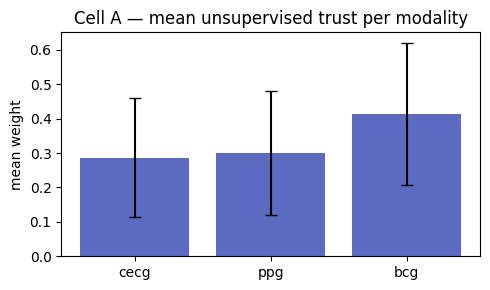

In [6]:
cellA_p, cellA_W = lopo_unsup("global")          # scope='global' == single shared learner

print("CELL A — single unsupervised learner over ALL SQI features")
print(f"  naive mean AUC      : {roc_auc_score(y, P.mean(1)):.3f}")
print(f"  Cell A (1 learner)  : {roc_auc_score(y, cellA_p):.3f}")
display(pd.DataFrame({"naive_mean": metrics(y, P.mean(1)),
                      "cellA_single_unsup": metrics(y, cellA_p)}).T.round(3))

plt.figure(figsize=(5, 3))
plt.bar(MODALITIES, cellA_W.mean(0), yerr=cellA_W.std(0), capsize=4, color="#5c6bc0")
plt.ylabel("mean weight"); plt.title("Cell A — mean unsupervised trust per modality")
plt.tight_layout(); plt.show()


## 6 · Cell B — SQI-only features, **three** unsupervised learners (one per modality)

**As requested:** train **only on SQI features**, with **three independent unsupervised learners** — one per
modality, each fit *only* on its own SQI block (cECG; PPG = ppg1+ppg2; BCG = bcg1+bcg2). Each learner
estimates its modality's quality independently; the three scores are placed on a common `[0,1]` scale
(robust min-max + composite-SQI orientation) and softmax-blended.

**Contrast with Cell A.** Cell A's single learner couples the modalities through one shared manifold (it can
exploit cross-modal quality correlation, e.g. global motion artefact); Cell B's three learners are
decoupled (each modality judged on its own terms, more robust to one modality's SQI being pathological).
Reporting both is exactly the kind of ablation a thesis wants.

CELL B — three unsupervised learners (method='pca')
  naive mean AUC          : 0.904
  Cell B (3 learners)     : 0.905


,acc,sens,spec,f1,auc
naive_mean,0.836,0.858,0.816,0.833,0.904
cellB_three_unsup,0.827,0.835,0.821,0.822,0.905


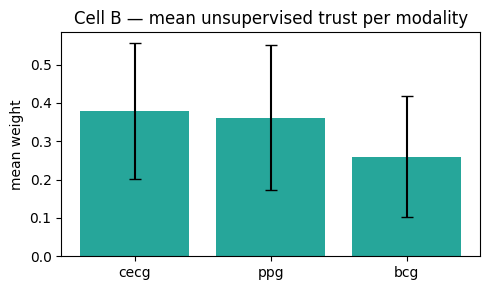

In [7]:
cellB_p, cellB_W = lopo_unsup("per_modality")    # three independent learners

print(f"CELL B — three unsupervised learners (method='{UW_METHOD}')")
print(f"  naive mean AUC          : {roc_auc_score(y, P.mean(1)):.3f}")
print(f"  Cell B (3 learners)     : {roc_auc_score(y, cellB_p):.3f}")

# optional: see the GMM backend too (one line; comment back in to compare)
# cellB_gmm = np.full(len(lab), np.nan)
# for tr, te in LeaveOneGroupOut().split(lab, y, groups):
#     g = UnsupervisedGate(scope="per_modality", method="gmm").fit(lab.iloc[tr])
#     cellB_gmm[te] = g.predict_proba(lab.iloc[te], P[te])
# print(f"  Cell B (gmm backend)    : {roc_auc_score(y, cellB_gmm):.3f}")

display(pd.DataFrame({"naive_mean": metrics(y, P.mean(1)),
                      "cellB_three_unsup": metrics(y, cellB_p)}).T.round(3))

plt.figure(figsize=(5, 3))
plt.bar(MODALITIES, cellB_W.mean(0), yerr=cellB_W.std(0), capsize=4, color="#26a69a")
plt.ylabel("mean weight"); plt.title("Cell B — mean unsupervised trust per modality")
plt.tight_layout(); plt.show()


## 7 · Head-to-head — unsupervised weighting vs. the supervised gate and the naive mean

For a fair comparison we re-run `04`'s **supervised** plain `GatingNet` (label-trained) here, then table all
combiners together. A patient-level bootstrap CI is added because, at ~40 patients, point-AUC differences
are noisy — the honest question is whether the **unsupervised** weighting *matches or beats* both the naive
mean and the supervised gate **without ever touching the labels**.

In [9]:
# Supervised plain gate, copied verbatim from 04 · Section 5 for a like-for-like baseline.
class GatingNet:
    def __init__(self, d_in, n_experts, hidden=8, lr=0.05, epochs=400, temp=1.0, wd=1e-3, seed=0):
        r = np.random.default_rng(seed)
        self.W1 = r.normal(0, 1/np.sqrt(d_in), (d_in, hidden)); self.b1 = np.zeros(hidden)
        self.W2 = r.normal(0, 0.01, (hidden, n_experts));       self.b2 = np.zeros(n_experts)
        self.lr, self.epochs, self.temp, self.wd = lr, epochs, temp, wd; self.mu = self.sd = None
    def _softmax(self, z):
        z = z/self.temp; z = z - z.max(1, keepdims=True); e = np.exp(z); return e/e.sum(1, keepdims=True)
    def weights(self, Xs):
        Xs = (Xs - self.mu)/self.sd; return self._softmax(np.tanh(Xs@self.W1+self.b1)@self.W2+self.b2)
    def fit(self, Xs, P, y):
        self.mu, self.sd = Xs.mean(0), Xs.std(0)+1e-8; Xn = (Xs-self.mu)/self.sd
        y = y.astype(float); eps = 1e-7
        for _ in range(self.epochs):
            h = np.tanh(Xn@self.W1+self.b1); w = self._softmax(h@self.W2+self.b2)
            ph = np.clip((w*P).sum(1), eps, 1-eps)
            dph = (ph-y)/(ph*(1-ph))/len(y)
            dz2 = (dph[:, None]*w*(P-ph[:, None]))/self.temp
            dh = (dz2@self.W2.T)*(1-h**2)
            self.W2 -= self.lr*(h.T@dz2+self.wd*self.W2); self.b2 -= self.lr*dz2.sum(0)
            self.W1 -= self.lr*(Xn.T@dh+self.wd*self.W1); self.b1 -= self.lr*dh.sum(0)
        return self
    def predict_proba(self, Xs, P): return (self.weights(Xs)*P).sum(1)

Xsqi = np.nan_to_num(lab[SQI_ALL].to_numpy(float))
sup = np.full(len(lab), np.nan)
for tr, te in LeaveOneGroupOut().split(Xsqi, y, groups):
    if len(np.unique(y[tr])) < 2:
        sup[te] = P[tr].mean(); continue
    sup[te] = GatingNet(Xsqi.shape[1], 3).fit(Xsqi[tr], P[tr], y[tr]).predict_proba(Xsqi[te], P[te])

preds = {"mean(experts)": P.mean(1), "SQI-gate (supervised)": sup,
         "UnsupGate (concept)": concept, "Cell A (1 unsup)": cellA_p, "Cell B (3 unsup)": cellB_p}

def patient_boot_auc(y, p, groups, n=1000, seed=0):
    rng = np.random.default_rng(seed); uniq = np.unique(groups); idx = {g: np.where(groups == g)[0] for g in uniq}
    aucs = []
    for _ in range(n):
        samp = np.concatenate([idx[g] for g in rng.choice(uniq, len(uniq), replace=True)])
        if len(np.unique(y[samp])) == 2: aucs.append(roc_auc_score(y[samp], p[samp]))
    return np.percentile(aucs, [2.5, 97.5])

rows = {}
for name, p in preds.items():
    lo, hi = patient_boot_auc(y, p, groups)
    rows[name] = {**metrics(y, p), "auc_lo": round(lo, 3), "auc_hi": round(hi, 3)}
display(pd.DataFrame(rows).T.round(3))


,acc,sens,spec,f1,auc,auc_lo,auc_hi
mean(experts),0.836,0.858,0.816,0.833,0.904,0.821,0.966
SQI-gate (supervised),0.832,0.847,0.818,0.828,0.896,0.808,0.960
UnsupGate (concept),0.827,0.835,0.821,0.822,0.905,0.821,0.966
Cell A (1 unsup),0.788,0.825,0.755,0.788,0.875,0.792,0.944
Cell B (3 unsup),0.827,0.835,0.821,0.822,0.905,0.821,0.966


## 8 · Complications found in the current system + improvement plan

**Complications identified while reading the repository (independent of the author's "dead-end" notes):**

1. **The supervised gate is structurally starved of signal.** `04`'s `GatingNet` trains only on the
   blended-probability BCE, which produces non-trivial gradient *only on windows where the experts disagree*
   — a small slice of the data. With ~40 independent patients (the real unit of independence, not the
   ~thousands of correlated windows) it is under-determined and slides below the naive mean. The
   reliability-gate and error-prediction variants patch this, but all of them still try to learn *routing
   from labels*, which is the wrong supervision for "which sensor to trust."

2. **Hand-set fusion weights.** The `composite` SQI hard-codes `(0.5, 0.3, 0.2)` weights over kSQI/pSQI/etc.
   Those are guesses; nothing learns them from data. This notebook's unsupervised learner replaces that hand
   weighting directly.

3. **`signal_loader` data-path issues.** `signal_loader.py` indexes hard-coded CSV columns
   (`cecg=col1, ppg1=col12, ppg2=col24, bcg1=col2, bcg2=col3`) with no header validation, casts the GT to
   `uint16` (any negative/odd-scaled export silently wraps), and `offset_correction` fills drift-shift edges
   with `0.0` while trims use `NaN` — two different sentinels the downstream SQI/feature code must treat
   consistently or quality scores get biased at window edges. Worth a schema check + a single missing-value
   convention.

4. **Patient-count ceiling, not architecture ceiling.** Every combiner is bottlenecked by ~40 patients and a
   weak label-routing signal. Anything that reduces dependence on the labels for *weighting* (this notebook)
   or adds data is higher-leverage than another supervised gate variant.

**Improvement plan (this notebook, then beyond):**

- **Adopt unsupervised weighting as the default combiner** when Cell A/B match-or-beat the naive mean and the
  supervised gate on the patient-bootstrap CIs. It is deployment-faithful (SQI-only, no GT) and not
  over-fit on 40 patients. Keep the floor + temperature so it can only ever *soften* toward the mean.
- **Tune `UW_METHOD/UW_BETA/UW_FLOOR` with nested LOPO** (inner split per fold) — never on the full set.
- **Semi-supervised extension:** use the unsupervised quality as a *prior* and let a tiny supervised head
  fine-tune it (regularised toward the unsupervised weights) — combines this notebook's robustness with any
  genuine label-routing signal that does exist.
- **Validate the SQI→reliability link** (already unsupervised-honest): correlate each modality's quality
  score with that expert's true per-window correctness; a positive, stable correlation is the evidence that
  the unsupervised weighting is doing real routing.
- **Fix the loader hardening items in (3)** so edge windows don't poison the very SQIs the weighting reads.
- **Report patient-level streaming detection** (latency + false-alarm), as `04 · 8c` notes, since the
  deployment goal is *early* AF flagging — not per-window AUC.

> The synthetic fallback above is only a scaffold to prove the code runs and behaves (quality-driven routing
> beats the mean, degenerate inputs are safe). The real numbers come from running Section 2 against the
> confidential cohort.